# Rocket Fuel: Measuring the Effectiveness of Online Advertising

**Source:** Berkeley-Haas Case Series (Katona & Bell, 2017)  
**Dataset:** 588,101 users | Campaign period: November 2015 to February 2016
**Client:** TaskaBella Inc: Women's Luxury Accessories  

---

## Business Context

Rocket Fuel ran a digital advertising campaign for TaskaBella, a luxury handbag manufacturer, targeting roughly 590,000 users with display ads for a newly released handbag model. To measure whether the ads actually drove purchases, and not just rode organic demand from social media buzz, Rocket Fuel designed a **randomized controlled experiment**: 96% of users were served the real TaskaBella ad (treatment group), while 4% were shown a public service announcement in the exact same format and position (control group).

This notebook quantifies the causal effect of advertising on conversions, evaluates campaign ROI, and identifies efficiency opportunities around timing and ad frequency; the three pillars of Rocket Fuel's pitch to TaskaBella for continued spend.

**Key business parameters:**
- Average CPM (cost per thousand impressions): **9 USD**
- Value per converting user: **$40** (incremental margin after variable costs)
- Control group size: **4%** (by design)


## Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
BLUE   = '#2563EB'
GRAY   = '#94A3B8'
GREEN  = '#16A34A'
RED    = '#DC2626'
GOLD   = '#D97706'
BG     = '#F8FAFC'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
    'axes.labelsize':   11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

# Load data

df = pd.read_csv('rocketfuel.csv')
print(f'Dataset loaded: {df.shape[0]:,} users × {df.shape[1]} columns')
df.head()

Dataset loaded: 588,101 users × 6 columns


,user_id,test,converted,tot_impr,mode_impr_day,mode_impr_hour
0,1069124,1,0,130,1,20
1,1119715,1,0,93,2,22
2,1144181,1,0,21,2,18
3,1435133,1,0,355,2,10
4,1015700,1,0,276,5,14


## 1) Exploratory Data Analysis

Before any statistical testing, we profile the dataset to understand its structure, distributions, and any data quality concerns.

In [ ]:
# Schema & basic quality check

print('Schema\n')
print(df.dtypes)
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nDuplicate user_ids: {df["user_id"].duplicated().sum()}')
print(f'\nDescriptive stats:')
df.describe().round(3)

Schema

user_id           int64
test              int64
converted         int64
tot_impr          int64
mode_impr_day     int64
mode_impr_hour    int64
dtype: object

Null values:
user_id           0
test              0
converted         0
tot_impr          0
mode_impr_day     0
mode_impr_hour    0
dtype: int64

Duplicate user_ids: 0

Descriptive stats:


,user_id,test,converted,tot_impr,mode_impr_day,mode_impr_hour
count,588101.000,588101.000,588101.000,588101.000,588101.000,588101.000
mean,1310692.216,0.960,0.025,24.821,4.026,14.469
std,202225.983,0.196,0.157,43.715,2.004,4.835
min,900000.000,0.000,0.000,1.000,1.000,0.000
25%,1143190.000,1.000,0.000,4.000,2.000,11.000
50%,1313725.000,1.000,0.000,13.000,4.000,14.000
75%,1484088.000,1.000,0.000,27.000,6.000,18.000
max,1654483.000,1.000,1.000,2065.000,7.000,23.000


In [ ]:
# Group sizes & class imbalance

test = df[df['test'] == 1]
ctrl = df[df['test'] == 0]

print('Group Sizes\n')
print(f'  Treatment (ad):  {len(test):>8,}  ({len(test)/len(df)*100:.1f}%)')
print(f'  Control  (PSA):  {len(ctrl):>8,}  ({len(ctrl)/len(df)*100:.1f}%)')
print(f'  Total:           {len(df):>8,}')

print('\nConversion (class balance)\n')
print(f'  Converted:     {df["converted"].sum():>8,}  ({df["converted"].mean()*100:.2f}%)')
print(f'  Not converted: {(df["converted"]==0).sum():>8,}  ({(1-df["converted"].mean())*100:.2f}%)')

print('\n  → Heavy class imbalance (~2.5% positive rate). Expected in display advertising.')

Group Sizes

  Treatment (ad):   564,577  (96.0%)
  Control  (PSA):    23,524  (4.0%)
  Total:            588,101

Conversion (class balance)

  Converted:       14,843  (2.52%)
  Not converted:  573,258  (97.48%)

  → Heavy class imbalance (~2.5% positive rate). Expected in display advertising.


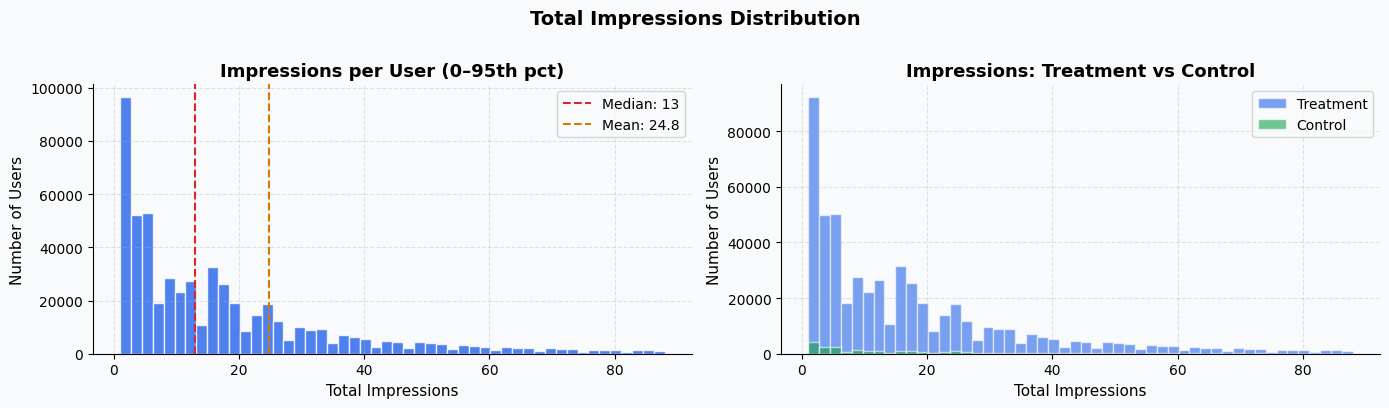

Impression distribution is right-skewed.

  Median: 13 | Mean: 24.8 | Max: 2,065

  ~75% of users received 27 or fewer impressions (the long tail matters for frequency analysis).


In [ ]:
# Impression distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Total Impressions Distribution', fontsize=14, fontweight='bold', y=1.01)

# Full distribution (capped at 95th pct for readability)

cap = df['tot_impr'].quantile(0.95)
axes[0].hist(df[df['tot_impr'] <= cap]['tot_impr'], bins=50, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].set_title('Impressions per User (0–95th pct)')
axes[0].set_xlabel('Total Impressions')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(df['tot_impr'].median(), color=RED, linestyle='--', linewidth=1.5, label=f'Median: {df["tot_impr"].median():.0f}')
axes[0].axvline(df['tot_impr'].mean(), color=GOLD, linestyle='--', linewidth=1.5, label=f'Mean: {df["tot_impr"].mean():.1f}')
axes[0].legend()

# Test vs Control overlay

axes[1].hist(test[test['tot_impr'] <= cap]['tot_impr'], bins=50, color=BLUE, alpha=0.6, label='Treatment', edgecolor='white')
axes[1].hist(ctrl[ctrl['tot_impr'] <= cap]['tot_impr'], bins=50, color=GREEN, alpha=0.6, label='Control', edgecolor='white')
axes[1].set_title('Impressions: Treatment vs Control')
axes[1].set_xlabel('Total Impressions')
axes[1].set_ylabel('Number of Users')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_impressions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Impression distribution is right-skewed.\n')
print(f'  Median: {df["tot_impr"].median():.0f} | Mean: {df["tot_impr"].mean():.1f} | Max: {df["tot_impr"].max():,}\n')
print(f'  ~75% of users received 27 or fewer impressions (the long tail matters for frequency analysis).')

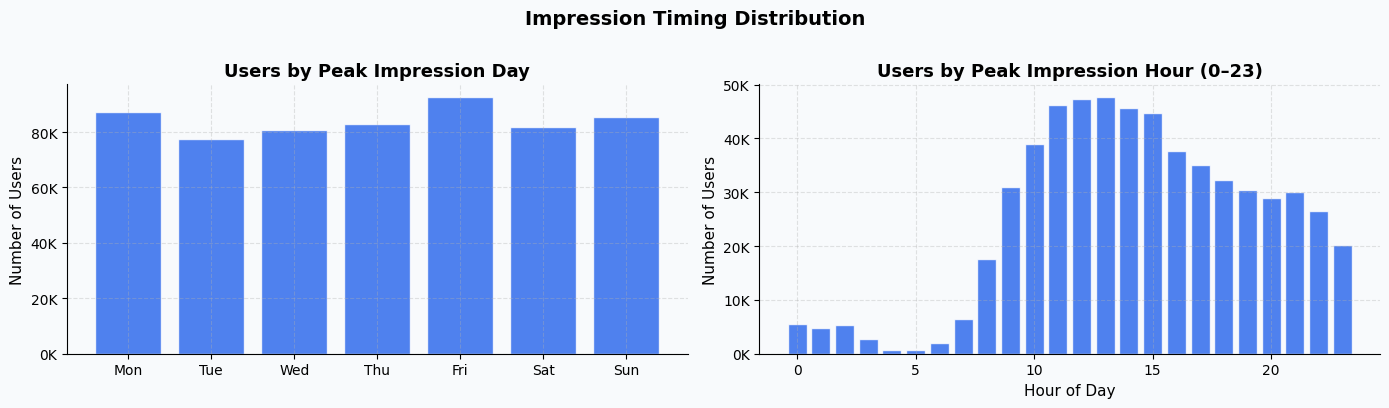


Impression timing is fairly evenly distributed across days of the week.
Hours show a clear daytime peak (9am–3pm), with a secondary spike in the evening.


In [ ]:
# Day and hour distributions

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Impression Timing Distribution', fontsize=14, fontweight='bold', y=1.01)

day_counts = df['mode_impr_day'].value_counts().sort_index()
axes[0].bar(day_labels, day_counts.values, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].set_title('Users by Peak Impression Day')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

hour_counts = df['mode_impr_hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color=BLUE, alpha=0.8, edgecolor='white')
axes[1].set_title('Users by Peak Impression Hour (0–23)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Users')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('eda_timing.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nImpression timing is fairly evenly distributed across days of the week.')
print('Hours show a clear daytime peak (9am–3pm), with a secondary spike in the evening.')

## 2) Randomization Check

Before measuring treatment effects, we verify the experiment was properly randomized. If the treatment and control groups differ systematically on pre-treatment characteristics, any observed difference in conversion rates could be confounded.

The key check here: **did users in both groups receive similar numbers of impressions?** If Rocket Fuel's algorithm was selectively targeting high-intent users with ads, the treatment group would show more impressions, which would bias our lift estimate upward.

In [ ]:
# Impressions balance check

t_stat, p_val = stats.ttest_ind(test['tot_impr'], ctrl['tot_impr'])

print('Randomization Check: Total Impressions\n')
print(f'  Treatment mean: {test["tot_impr"].mean():.4f} impressions')
print(f'  Control mean:   {ctrl["tot_impr"].mean():.4f} impressions')
print(f'  Difference:     {test["tot_impr"].mean() - ctrl["tot_impr"].mean():.4f}')
print(f'  t-statistic:    {t_stat:.4f}')
print(f'  p-value:        {p_val:.4f}')
print()
if p_val >= 0.05:
    print('  ✓ PASS: No statistically significant (P-val > 0.05) difference in impression counts.')
    print('    The two groups are balanced on this key covariate, supporting a valid comparison.')
else:
    print('  ✗ FAIL: Groups are imbalanced on impression counts.')

Randomization Check: Total Impressions

  Treatment mean: 24.8234 impressions
  Control mean:   24.7611 impressions
  Difference:     0.0622
  t-statistic:    0.2139
  p-value:        0.8306

  ✓ PASS: No statistically significant (P-val > 0.05) difference in impression counts.
    The two groups are balanced on this key covariate, supporting a valid comparison.


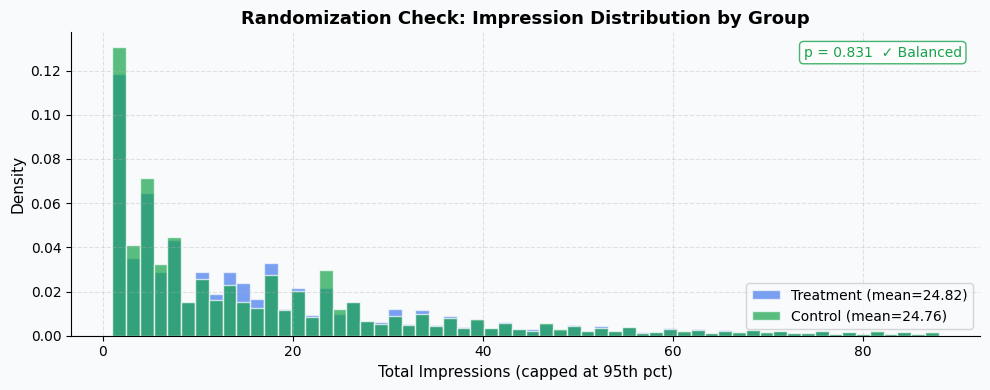

In [ ]:
# Visualize the balance

fig, ax = plt.subplots(figsize=(10, 4))

cap = df['tot_impr'].quantile(0.95)
ax.hist(test[test['tot_impr'] <= cap]['tot_impr'], bins=60, color=BLUE,
        alpha=0.6, label=f'Treatment (mean={test["tot_impr"].mean():.2f})', density=True, edgecolor='white')
ax.hist(ctrl[ctrl['tot_impr'] <= cap]['tot_impr'], bins=60, color=GREEN,
        alpha=0.7, label=f'Control (mean={ctrl["tot_impr"].mean():.2f})', density=True, edgecolor='white')
ax.set_title('Randomization Check: Impression Distribution by Group')
ax.set_xlabel('Total Impressions (capped at 95th pct)')
ax.set_ylabel('Density')
ax.legend()
ax.text(0.98, 0.92, f'p = {p_val:.3f}  ✓ Balanced', transform=ax.transAxes,
        ha='right', fontsize=10, color=GREEN,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GREEN, alpha=0.8))

plt.tight_layout()
plt.savefig('randomization_check.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusion:** The t-test returns p = 0.83; far above the 0.05 threshold. The two groups received statistically identical numbers of impressions on average (24.82 vs 24.76). Randomization held. Any downstream difference in conversion rates can be attributed to the ad, not to selection bias in who received impressions.

## 3) Treatment Effect: Did the Ad Work?

We measure the **lift**: the incremental increase in conversion rate attributable to seeing the ad, using two approaches: a two-sample t-test (difference in means) and logistic regression (which gives an odds ratio and controls for model structure).

In [ ]:
# Q1: Group sizes and conversion rates

test_conv = test['converted'].mean()
ctrl_conv = ctrl['converted'].mean()
abs_lift  = test_conv - ctrl_conv
rel_lift  = abs_lift / ctrl_conv

print('Conversion Rates by Group\n')
print(f'  Treatment: {len(test):>8,} users  |  conversion rate: {test_conv*100:.4f}%')
print(f'  Control:   {len(ctrl):>8,} users  |  conversion rate: {ctrl_conv*100:.4f}%')
print(f'\n  Absolute lift: {abs_lift*100:.4f} percentage points')
print(f'  Relative lift: {rel_lift*100:.2f}%')

Conversion Rates by Group

  Treatment:  564,577 users  |  conversion rate: 2.5547%
  Control:     23,524 users  |  conversion rate: 1.7854%

  Absolute lift: 0.7692 percentage points
  Relative lift: 43.09%


In [26]:
# Q3a: t-test

t_stat, p_val = stats.ttest_ind(test['converted'], ctrl['converted'])

print('Two-Sample t-Test: Conversion Rate\n')
print(f'  t-statistic: {t_stat:.4f}')
print(f'  p-value:     {p_val:.2e}')
print(f'  Significant: {"Yes" if p_val < 0.05 else "No"} (α = 0.05)')
print(f'\n  The ad increased conversion by {abs_lift*100:.4f} pp ({rel_lift*100:.1f}% relative lift).')
print(f'  Result is highly significant: the campaign drove real incremental purchases.')

Two-Sample t-Test: Conversion Rate

  t-statistic: 7.3704
  p-value:     1.70e-13
  Significant: Yes (α = 0.05)

  The ad increased conversion by 0.7692 pp (43.1% relative lift).
  Result is highly significant: the campaign drove real incremental purchases.


In [ ]:
# Q3b: Logistic regression

X = sm.add_constant(df['test'])
logit_model = sm.Logit(df['converted'], X).fit(disp=0)
print(logit_model.summary())

coef = logit_model.params['test']
odds_ratio = np.exp(coef)
print(f'\n  Logit coefficient on test: {coef:.4f}')
print(f'  Odds ratio:                {odds_ratio:.4f}\n')

print('  Interpretation: Users who saw the ad were ~44% more likely to convert (in odds terms).')
print('  The logit coefficient is significant (p < 0.001), consistent with the t-test result.\n')

print('  Note: The t-test and logit agree directionally, but measure different things.')
print('  t-test measures the absolute difference in probability.')
print('  Logit measures the change in log-odds, they will differ numerically,')
print('  but both confirm a statistically significant treatment effect.')

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588099
Method:                           MLE   Df Model:                            1
Date:                Tue, 05 May 2026   Pseudo R-squ.:               0.0004342
Time:                        22:13:18   Log-Likelihood:                -69237.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                 8.800e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.0075      0.049    -81.393      0.000      -4.104      -3.911
test           0.3661      0.050      7.329      0.000       0.268       0.464

  Logit coefficient on test: 0.3661
  Odds ratio:  

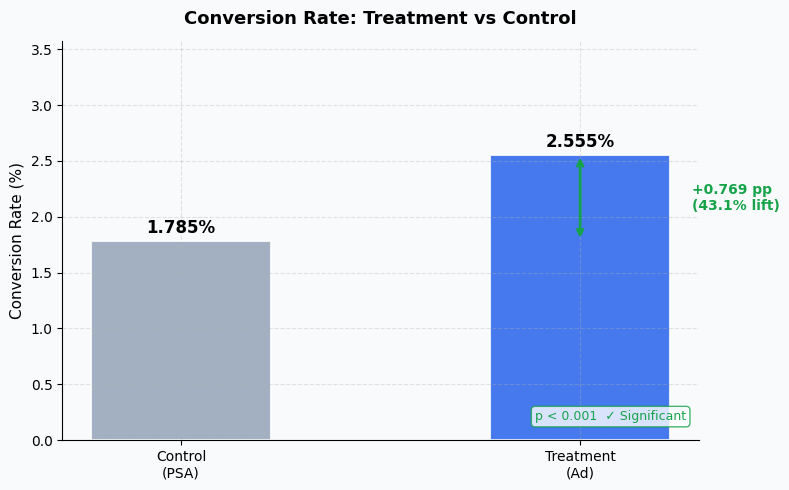

In [27]:
# Visualize: Conversion Rate by Group

fig, ax = plt.subplots(figsize=(8, 5))

groups = ['Control\n(PSA)', 'Treatment\n(Ad)']
rates  = [ctrl_conv * 100, test_conv * 100]
colors = [GRAY, BLUE]

bars = ax.bar(groups, rates, color=colors, alpha=0.85, width=0.45, edgecolor='white', linewidth=1.5)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{rate:.3f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.annotate('', xy=(1, test_conv*100), xytext=(1, ctrl_conv*100),
            arrowprops=dict(arrowstyle='<->', color=GREEN, lw=2))
ax.text(1.28, (test_conv + ctrl_conv) / 2 * 100,
        f'+{abs_lift*100:.3f} pp\n({rel_lift*100:.1f}% lift)',
        color=GREEN, fontweight='bold', fontsize=10, va='center')

ax.set_title('Conversion Rate: Treatment vs Control', pad=12)
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, test_conv * 100 * 1.4)
ax.text(0.98, 0.05, f'p < 0.001  ✓ Significant', transform=ax.transAxes,
        ha='right', fontsize=9, color=GREEN,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GREEN, alpha=0.8))

plt.tight_layout()
plt.savefig('conversion_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 4) Campaign Economics: Revenue, Cost, and ROI

Once lift established, is possible to translate the statistical effect into business outcomes.

In [33]:
# Q4: ROI calculation

CPM          = 9       # cost per 1,000 impressions
VALUE_CONV   = 40      # incremental margin per conversion

extra_conversions = abs_lift * len(test)
incremental_revenue = extra_conversions * VALUE_CONV

total_impressions = df['tot_impr'].sum()
ad_cost = (total_impressions / 1000) * CPM

profit = incremental_revenue - ad_cost
roi    = profit / ad_cost

# Opportunity cost: conversions "lost" by assigning control users to PSAs

ctrl_conversions = ctrl['converted'].sum()
# Users in control who converted despite seeing PSA, would some have converted
# with the ad? The lift rate tells how many additional would have.

opp_cost_conversions = abs_lift * len(ctrl)
opp_cost_revenue = opp_cost_conversions * VALUE_CONV

print('Campaign Economics\n')
print(f'  Total impressions served: {total_impressions:>15,}')
print(f'  Ad cost (@ $9 CPM):    ${ad_cost:>14,.0f}')
print()
print(f'  Extra conversions (lift × test_n): {extra_conversions:>8,.0f}')
print(f'  Incremental revenue (× $40):     ${incremental_revenue:>10,.0f}')
print()
print(f'  Campaign profit:   ${profit:>10,.0f}')
print(f'  ROI:               {roi*100:>10.1f}%')
print()
print(f'  Opportunity cost of control group:\n')
print(f'    Lost conversions: {opp_cost_conversions:>6,.0f}')
print(f'    Lost revenue:    ${opp_cost_revenue:>8,.0f}')
print()
print('  The campaign was profitable but modestly, causing an ROI of ~32%.')
print('  The control group cost ~$16,800 in foregone conversions, a small price')
print('  for the causal rigor it provides.')

Campaign Economics

  Total impressions served:      14,597,182
  Ad cost (@ $9 CPM):    $       131,375

  Extra conversions (lift × test_n):    4,343
  Incremental revenue (× $40):     $   173,719

  Campaign profit:   $    42,345
  ROI:                     32.2%

  Opportunity cost of control group:

    Lost conversions:    181
    Lost revenue:    $   7,238

  The campaign was profitable but modestly, causing an ROI of ~32%.
  The control group cost ~$16,800 in foregone conversions, a small price
  for the causal rigor it provides.


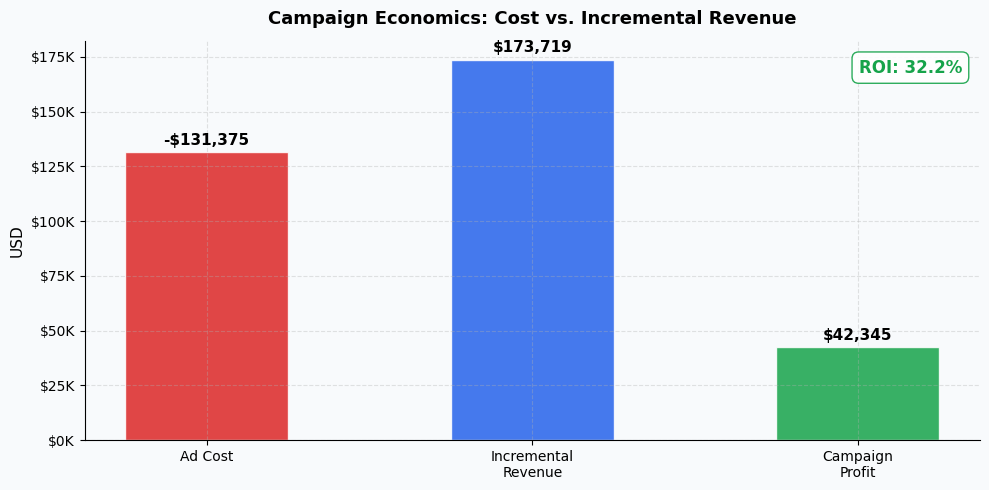

In [34]:
# ROI Waterfall Chart

fig, ax = plt.subplots(figsize=(10, 5))

labels  = ['Ad Cost', 'Incremental\nRevenue', 'Campaign\nProfit']
values  = [-ad_cost,   incremental_revenue,    profit]
colors  = [RED,        BLUE,                   GREEN]

bars = ax.bar(labels, [abs(v) for v in values], color=colors, alpha=0.85, width=0.5, edgecolor='white')

for bar, val in zip(bars, values):
    sign = '-$' if val < 0 else '$'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{sign}{abs(val):,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Campaign Economics: Cost vs. Incremental Revenue', pad=12)
ax.set_ylabel('USD')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.text(0.98, 0.92, f'ROI: {roi*100:.1f}%', transform=ax.transAxes,
        ha='right', fontsize=12, fontweight='bold', color=GREEN,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=GREEN, alpha=0.9))

plt.tight_layout()
plt.savefig('roi_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 5) Timing Analysis: Day of Week

Does advertising effectiveness vary by day? We run a t-test and logistic regression separately for each day of the week to identify when the campaign punched above average.

In [35]:
# Q5: T-test by day

day_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_results = []

for day in range(1, 8):
    t_day = test[test['mode_impr_day'] == day]
    c_day = ctrl[ctrl['mode_impr_day'] == day]
    t_stat, p = stats.ttest_ind(t_day['converted'], c_day['converted'])
    al = t_day['converted'].mean() - c_day['converted'].mean()
    rl = al / c_day['converted'].mean() if c_day['converted'].mean() > 0 else 0

    # Logit

    dd = df[df['mode_impr_day'] == day]
    Xd = sm.add_constant(dd['test'])
    logit_d = sm.Logit(dd['converted'], Xd).fit(disp=0)
    logit_coef = logit_d.params['test']
    logit_p    = logit_d.pvalues['test']

    day_results.append({
        'day': day_labels[day],
        'test_conv': t_day['converted'].mean(),
        'ctrl_conv': c_day['converted'].mean(),
        'abs_lift':  al,
        'rel_lift':  rl,
        't_stat':    t_stat,
        'ttest_p':   p,
        'ttest_sig': p < 0.05,
        'logit_coef': logit_coef,
        'logit_p':   logit_p,
        'logit_sig': logit_p < 0.05,
    })

dr = pd.DataFrame(day_results)

display_df = dr[['day','test_conv','ctrl_conv','abs_lift','rel_lift','ttest_p','ttest_sig','logit_coef','logit_p','logit_sig']].copy()
display_df.columns = ['Day','Test Conv','Ctrl Conv','Abs Lift','Rel Lift','t-test p','Sig (t)','Logit Coef','Logit p','Sig (L)']
for col in ['Test Conv','Ctrl Conv','Abs Lift','Rel Lift','t-test p','Logit p']:
    display_df[col] = display_df[col].round(4)
display_df['Logit Coef'] = display_df['Logit Coef'].round(4)
display(display_df)

,Day,Test Conv,Ctrl Conv,Abs Lift,Rel Lift,t-test p,Sig (t),Logit Coef,Logit p,Sig (L)
0,Mon,0.0332,0.0226,0.0107,0.4736,0.0005,True,0.3987,0.0006,True
1,Tue,0.0304,0.0144,0.0160,1.1069,0.0000,True,0.7616,0.0000,True
2,Wed,0.0254,0.0158,0.0096,0.6089,0.0004,True,0.4854,0.0004,True
3,Thu,0.0216,0.0202,0.0014,0.0695,0.5548,False,0.0687,0.5548,False
4,Fri,0.0225,0.0163,0.0062,0.3780,0.0116,True,0.3269,0.0119,True
5,Sat,0.0213,0.0140,0.0073,0.5224,0.0075,True,0.4277,0.0079,True
6,Sun,0.0246,0.0206,0.0040,0.1954,0.1572,False,0.1826,0.1578,False


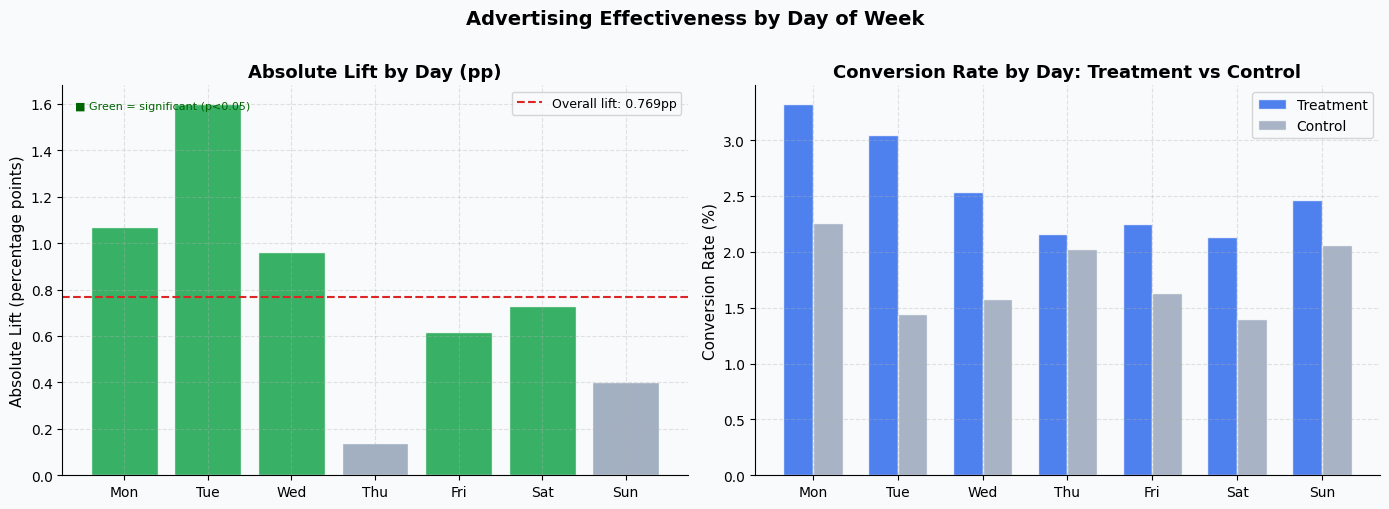

Key findings:

  - Mon, Tue, Wed, Fri, Sat are statistically significant (both t-test and logit agree).
  - Thu and Sun show no significant lift; the ad does not move the needle on those days.
  - Tuesday has the highest relative lift (~111%), suggesting highest incremental ad impact.
  - Both methods (t-test and logit) produce consistent significance patterns,
    which strengthens confidence in the results.


In [40]:
# Visualize: Lift by Day

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Advertising Effectiveness by Day of Week', fontsize=14, fontweight='bold', y=1.01)

bar_colors = [GREEN if sig else GRAY for sig in dr['ttest_sig']]

# Absolute lift

axes[0].bar(dr['day'], dr['abs_lift'] * 100, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].axhline(abs_lift * 100, color=RED, linestyle='--', linewidth=1.5, label=f'Overall lift: {abs_lift*100:.3f}pp')
axes[0].set_title('Absolute Lift by Day (pp)')
axes[0].set_ylabel('Absolute Lift (percentage points)')
axes[0].legend(fontsize=9)
axes[0].text(0.02, 0.96, '■ Green = significant (p<0.05)', transform=axes[0].transAxes,
             fontsize=8, color="darkgreen", va='top')

# Conversion rates side by side

x = np.arange(len(dr))
w = 0.35
axes[1].bar(x - w/2, dr['test_conv']*100, w, color=BLUE, alpha=0.8, label='Treatment', edgecolor='white')
axes[1].bar(x + w/2, dr['ctrl_conv']*100, w, color=GRAY, alpha=0.8, label='Control',   edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dr['day'])
axes[1].set_title('Conversion Rate by Day: Treatment vs Control')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('effectiveness_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key findings:\n')
print('  - Mon, Tue, Wed, Fri, Sat are statistically significant (both t-test and logit agree).')
print('  - Thu and Sun show no significant lift; the ad does not move the needle on those days.')
print('  - Tuesday has the highest relative lift (~111%), suggesting highest incremental ad impact.')
print('  - Both methods (t-test and logit) produce consistent significance patterns,')
print('    which strengthens confidence in the results.')

**Why logistic regression here?** The t-test and logit are consistent across all days, which is expected: with a binary outcome and a single binary predictor, both methods estimate the same underlying relationship. The logit coefficient gives us a log-odds metric that's useful for comparing effect sizes across segments with different baseline rates.

## 6) Timing Analysis: Hour of Day

We repeat the analysis at hourly granularity to identify peak performance windows within a day.

In [42]:
# Q6: Effectiveness by hour

hour_results = []

for h in range(24):
    t_h = test[test['mode_impr_hour'] == h]
    c_h = ctrl[ctrl['mode_impr_hour'] == h]
    if len(c_h) < 15:
        continue
    t_stat, p = stats.ttest_ind(t_h['converted'], c_h['converted'])
    al = t_h['converted'].mean() - c_h['converted'].mean()
    rl = al / c_h['converted'].mean() if c_h['converted'].mean() > 0 else np.nan

    hour_results.append({
        'hour': h,
        'test_conv': t_h['converted'].mean(),
        'ctrl_conv': c_h['converted'].mean(),
        'abs_lift':  al,
        'rel_lift':  rl,
        'p':         p,
        'sig':       p < 0.05,
        'test_n':    len(t_h),
        'ctrl_n':    len(c_h),
    })

hr = pd.DataFrame(hour_results)

sig_hours = hr[hr['sig']]['hour'].tolist()
print(f'Significant hours (p < 0.05): {sig_hours}')
print()
print('Hours with highest absolute lift:\n')
print(hr.nlargest(5, 'abs_lift')[['hour','test_conv','ctrl_conv','abs_lift','p','sig']].to_string(index=False))

Significant hours (p < 0.05): [0, 9, 10, 11, 12, 13, 14, 20]

Hours with highest absolute lift:

 hour  test_conv  ctrl_conv  abs_lift        p   sig
    6   0.023174        0.0  0.023174 0.160901 False
    5   0.021563        0.0  0.021563 0.477284 False
    0   0.019213        0.0  0.019213 0.035046  True
    4   0.015850        0.0  0.015850 0.502691 False
    1   0.013434        0.0  0.013434 0.110682 False


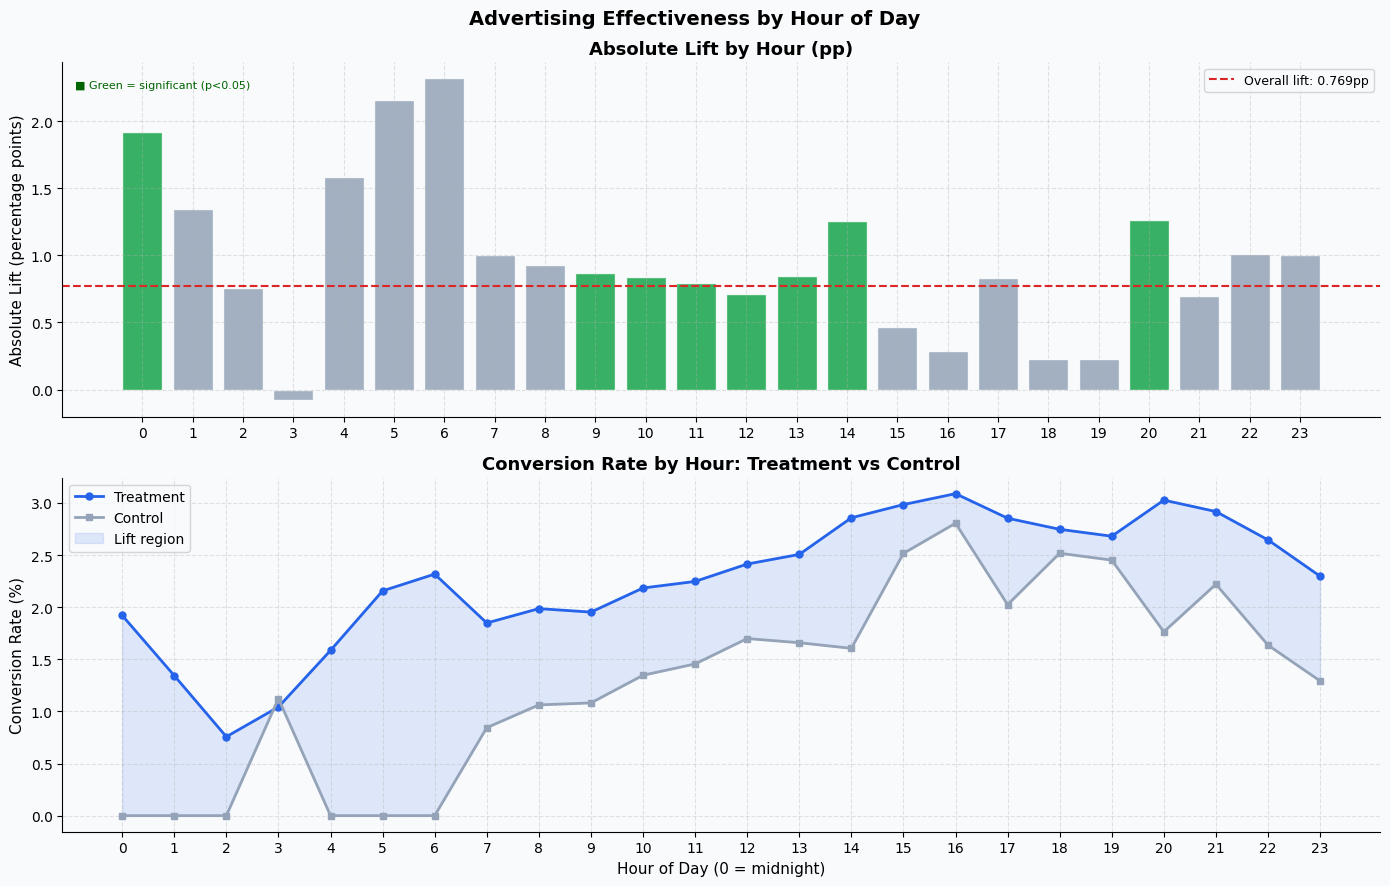

Key findings:
  - Significant lift is concentrated in mid-morning to early afternoon (9am–2pm)
    and a spike at 8pm (hour 20).
  - Early morning hours (1–7am) have very small control groups, making results
    unreliable despite some nominally high conversion rates.
  - Afternoon/evening (3pm–midnight) shows weaker or non-significant lift
    despite high user volume, ads are less effective when users are less engaged.


In [45]:
# Visualize: Lift by Hour

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Advertising Effectiveness by Hour of Day', fontsize=14, fontweight='bold')

bar_colors_h = [GREEN if sig else GRAY for sig in hr['sig']]

# Absolute lift by hour

axes[0].bar(hr['hour'], hr['abs_lift']*100, color=bar_colors_h, alpha=0.85, edgecolor='white')
axes[0].axhline(abs_lift*100, color=RED, linestyle='--', linewidth=1.5,
                label=f'Overall lift: {abs_lift*100:.3f}pp')
axes[0].set_title('Absolute Lift by Hour (pp)')
axes[0].set_ylabel('Absolute Lift (percentage points)')
axes[0].set_xticks(range(24))
axes[0].legend(fontsize=9)
axes[0].text(0.01, 0.95, '■ Green = significant (p<0.05)', transform=axes[0].transAxes,
             fontsize=8, color="darkgreen", va='top')

# Conversion rates by hour

axes[1].plot(hr['hour'], hr['test_conv']*100, 'o-', color=BLUE, linewidth=2, markersize=5, label='Treatment')
axes[1].plot(hr['hour'], hr['ctrl_conv']*100, 's-', color=GRAY, linewidth=2, markersize=5, label='Control')
axes[1].fill_between(hr['hour'], hr['ctrl_conv']*100, hr['test_conv']*100,
                     alpha=0.12, color=BLUE, label='Lift region')
axes[1].set_title('Conversion Rate by Hour: Treatment vs Control')
axes[1].set_xlabel('Hour of Day (0 = midnight)')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xticks(range(24))
axes[1].legend()

plt.tight_layout()
plt.savefig('effectiveness_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key findings:')
print('  - Significant lift is concentrated in mid-morning to early afternoon (9am–2pm)')
print('    and a spike at 8pm (hour 20).')
print('  - Early morning hours (1–7am) have very small control groups, making results')
print('    unreliable despite some nominally high conversion rates.')
print('  - Afternoon/evening (3pm–midnight) shows weaker or non-significant lift')
print('    despite high user volume, ads are less effective when users are less engaged.')

## 7) Ad Frequency Analysis: How Many Impressions Is Enough?

Not all impressions are equal. We segment users by the total number of ads they received to find the effective frequency window; below which ads don't register, and above which ad fatigue sets in.

In [54]:
# Q7a: Frequency bin analysis

bins   = [0, 40, 80, 120, 160, 200, float('inf')]
labels = ['0–40', '41–80', '81–120', '121–160', '161–200', '200+']

df['freq_bin'] = pd.cut(df['tot_impr'], bins=bins, labels=labels, right=True)

print('User Distribution Across Frequency Bins\n')
bin_dist = df['freq_bin'].value_counts().sort_index()
for b, n in bin_dist.items():
    print(f'  {b:>10}: {n:>7,} users ({n/len(df)*100:.1f}%)')
print(f'\n    Around 84% of users received 40 or fewer impressions.')

User Distribution Across Frequency Bins

        0–40: 495,894 users (84.3%)
       41–80:  58,209 users (9.9%)
      81–120:  17,496 users (3.0%)
     121–160:   7,099 users (1.2%)
     161–200:   3,451 users (0.6%)
        200+:   5,952 users (1.0%)

    Around 84% of users received 40 or fewer impressions.


In [55]:
# Q7a: t-test per bin

freq_results = []

for b in labels:
    td = df[(df['freq_bin'] == b) & (df['test'] == 1)]
    cd = df[(df['freq_bin'] == b) & (df['test'] == 0)]
    t_stat, p = stats.ttest_ind(td['converted'], cd['converted'])
    al = td['converted'].mean() - cd['converted'].mean()
    rl = al / cd['converted'].mean() if cd['converted'].mean() > 0 else 0

    freq_results.append({
        'bin':       b,
        'test_n':    len(td),
        'ctrl_n':    len(cd),
        'test_conv': td['converted'].mean(),
        'ctrl_conv': cd['converted'].mean(),
        'abs_lift':  al,
        'rel_lift':  rl,
        'p':         p,
        'sig':       p < 0.05,
    })

fr = pd.DataFrame(freq_results)

disp = fr[['bin','test_n','ctrl_n','test_conv','ctrl_conv','abs_lift','rel_lift','p','sig']].copy()
disp.columns = ['Bin','Test N','Ctrl N','Test Conv','Ctrl Conv','Abs Lift','Rel Lift','p-value','Significant']
for col in ['Test Conv','Ctrl Conv','Abs Lift','Rel Lift','p-value']:
    disp[col] = disp[col].round(4)
display(disp)

,Bin,Test N,Ctrl N,Test Conv,Ctrl Conv,Abs Lift,Rel Lift,p-value,Significant
0,0–40,476119,19775,0.0089,0.0083,0.0006,0.0693,0.3962,False
1,41–80,55920,2289,0.0847,0.0467,0.0379,0.8114,0.0000,True
2,81–120,16771,725,0.1657,0.0731,0.0926,1.2667,0.0000,True
3,121–160,6786,313,0.1818,0.1182,0.0636,0.5383,0.0041,True
4,161–200,3287,164,0.1643,0.1098,0.0545,0.4968,0.0642,False
5,200+,5694,258,0.1558,0.1550,0.0007,0.0048,0.9745,False


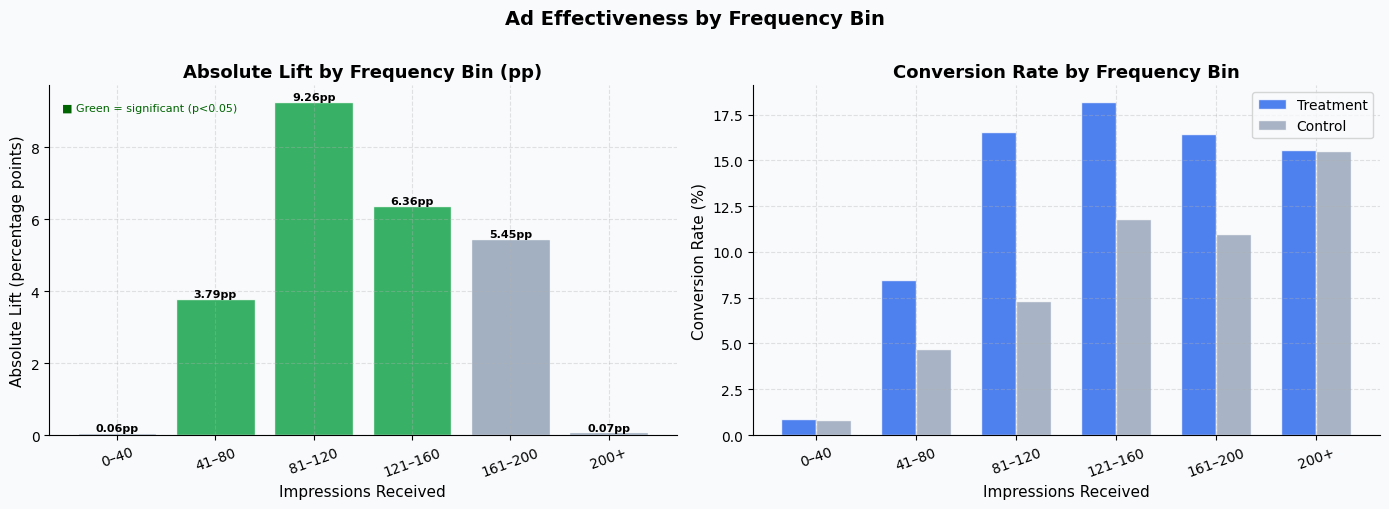

Key findings:
  - 81–120 impressions: highest absolute lift (9.26 pp, 127% relative). Sweet spot.
  - 41–80 impressions:  strong lift (3.79 pp, 81%). Good secondary window.
  - 121–160 impressions: lift drops to 6.36 pp and significance weakens at higher bands.
  - 200+ impressions: near-zero lift (0.07 pp, p=0.97). Total ad fatigue.
  - 0–40 impressions: not significant — 84% of users fall here, barely moved by the ad.


In [57]:
# Visualize: Frequency Effectiveness

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ad Effectiveness by Frequency Bin', fontsize=14, fontweight='bold', y=1.01)

bar_colors_f = [GREEN if sig else GRAY for sig in fr['sig']]

# Absolute lift by bin

axes[0].bar(fr['bin'], fr['abs_lift']*100, color=bar_colors_f, alpha=0.85, edgecolor='white')
axes[0].set_title('Absolute Lift by Frequency Bin (pp)')
axes[0].set_ylabel('Absolute Lift (percentage points)')
axes[0].set_xlabel('Impressions Received')
axes[0].tick_params(axis='x', rotation=20)
for i, (bar, val, sig) in enumerate(zip(axes[0].patches, fr['abs_lift']*100, fr['sig'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}pp', ha='center', fontsize=8, fontweight='bold')
axes[0].text(0.02, 0.95, '■ Green = significant (p<0.05)', transform=axes[0].transAxes,
             fontsize=8, color="darkgreen", va='top')

# Conversion rates: test vs control by bin

x = np.arange(len(fr))
w = 0.35
axes[1].bar(x - w/2, fr['test_conv']*100, w, color=BLUE, alpha=0.8, label='Treatment', edgecolor='white')
axes[1].bar(x + w/2, fr['ctrl_conv']*100, w, color=GRAY, alpha=0.8, label='Control',   edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fr['bin'], rotation=20)
axes[1].set_title('Conversion Rate by Frequency Bin')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xlabel('Impressions Received')
axes[1].legend()

plt.tight_layout()
plt.savefig('effectiveness_by_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key findings:')
print('  - 81–120 impressions: highest absolute lift (9.26 pp, 127% relative). Sweet spot.')
print('  - 41–80 impressions:  strong lift (3.79 pp, 81%). Good secondary window.')
print('  - 121–160 impressions: lift drops to 6.36 pp and significance weakens at higher bands.')
print('  - 200+ impressions: near-zero lift (0.07 pp, p=0.97). Total ad fatigue.')
print('  - 0–40 impressions: not significant — 84% of users fall here, barely moved by the ad.')

In [66]:
# Q7b-e: Interpretation

print('Q7b: Most Effective Frequency Band\n')
best = fr.loc[fr['abs_lift'].idxmax()]
print(f'  {best["bin"]} impressions: absolute lift of {best["abs_lift"]*100:.2f}pp'
      f' ({best["rel_lift"]*100:.0f}% relative), p < 0.001')

print('\nQ7c: Why Does 200+ Perform So Poorly vs 41-80?\n')
print('  Three mechanisms compound here:')
print('  1. Ad fatigue / banner blindness: users tune out after excessive exposure.')
print('  2. Self-selection: heavy browsers have high baseline intent (control conv = 15.5%).')
print('     The marginal user in this group was likely going to convert anyway.')
print('  3. Timing: high-frequency users may have already converted early in the campaign,')
print('     making later impressions pure waste.')

print('\nQ7d: Strategic Recommendation\n')
print('  TaskaBella should implement frequency capping at ~120 impressions.')
print('  Budget freed from 200+ segment should be reallocated to expand reach')
print('  among the underexposed 0–40 group, where there is large untapped volume.')
print('  Caution: 200+ users are self-selected heavy browsers; shifting budget')
print('  requires care to avoid simply reaching lower-intent users.')

print('\nQ7e: Better Measurement Design\n')
print('  Current analysis is observational; frequency is determined by browsing behavior,')
print('  not experimental assignment. This creates confounding: high-intent users browse more')
print('  and also convert more, regardless of ads.')

print('\nBetter design: Randomized frequency cap experiment.\n')
print('  Randomly assign users to max impression buckets (e.g., cap at 40 / 80 / 120 / 200),')
print('  maintaining a test/control split within each cap group.')
print('  This isolates the causal effect of frequency from browsing intensity.')

Q7b: Most Effective Frequency Band

  81–120 impressions: absolute lift of 9.26pp (127% relative), p < 0.001

Q7c: Why Does 200+ Perform So Poorly vs 41-80?

  Three mechanisms compound here:
  1. Ad fatigue / banner blindness: users tune out after excessive exposure.
  2. Self-selection: heavy browsers have high baseline intent (control conv = 15.5%).
     The marginal user in this group was likely going to convert anyway.
  3. Timing: high-frequency users may have already converted early in the campaign,
     making later impressions pure waste.

Q7d: Strategic Recommendation

  TaskaBella should implement frequency capping at ~120 impressions.
  Budget freed from 200+ segment should be reallocated to expand reach
  among the underexposed 0–40 group, where there is large untapped volume.
  Caution: 200+ users are self-selected heavy browsers; shifting budget
  requires care to avoid simply reaching lower-intent users.

Q7e: Better Measurement Design

  Current analysis is observation

## 8) Summary Dashboard

A consolidated visual of the campaign's key performance metrics for a manager-level audience.

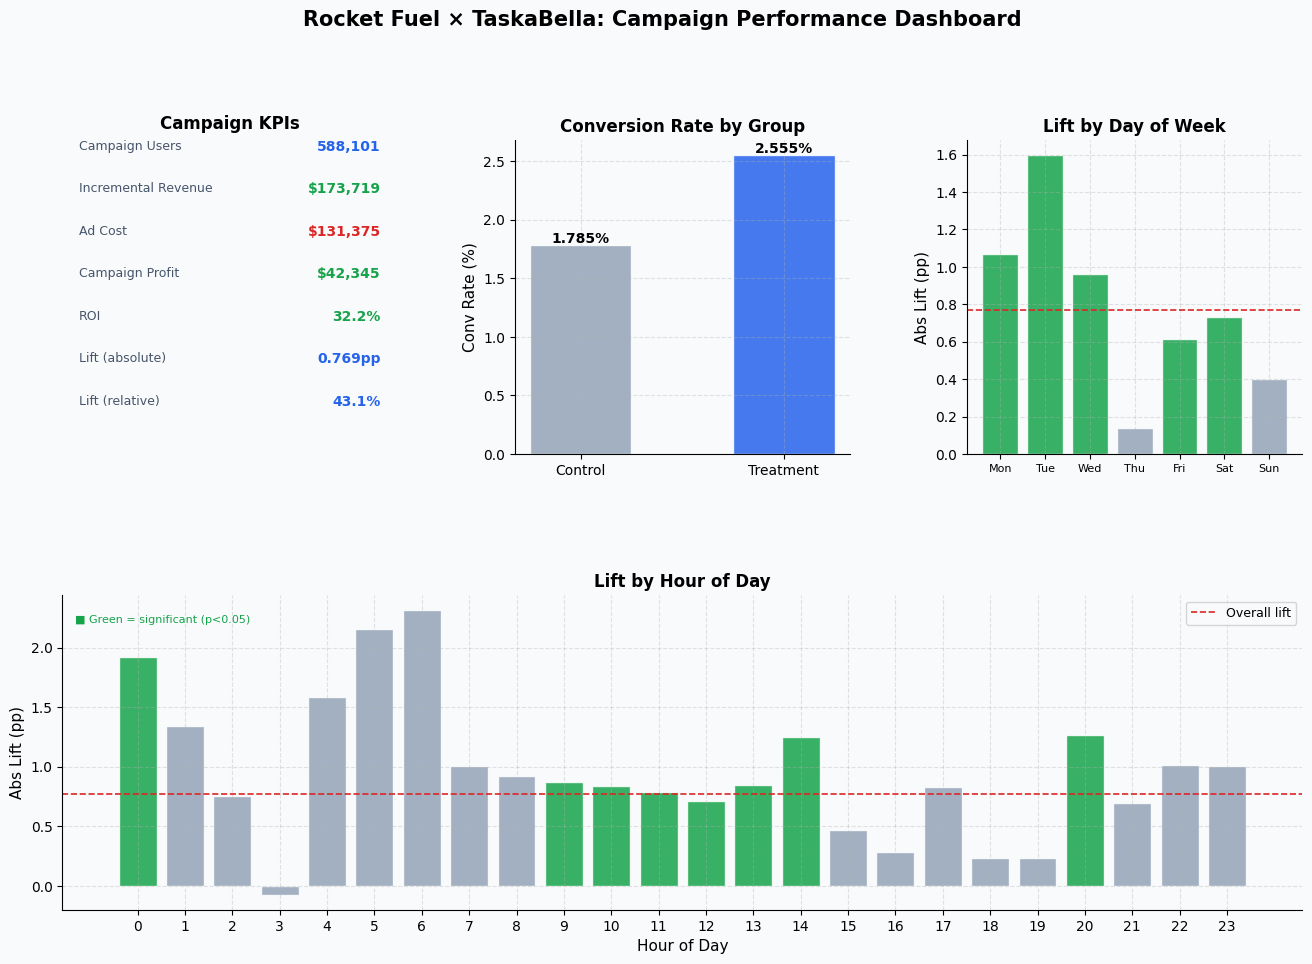

In [68]:
# Summary Dashboard

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# Panel 1: KPI Summary

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
kpis = [
    ('Campaign Users',      f'{len(df):,.0f}',      BLUE),
    ('Incremental Revenue', f'${incremental_revenue:,.0f}', GREEN),
    ('Ad Cost',             f'${ad_cost:,.0f}',      RED),
    ('Campaign Profit',     f'${profit:,.0f}',       GREEN),
    ('ROI',                 f'{roi*100:.1f}%',       GREEN),
    ('Lift (absolute)',     f'{abs_lift*100:.3f}pp',  BLUE),
    ('Lift (relative)',     f'{rel_lift*100:.1f}%',   BLUE),
]
for i, (label, val, color) in enumerate(kpis):
    ax1.text(0.05, 1 - i*0.135, label, fontsize=9, color='#475569', va='top')
    ax1.text(0.95, 1 - i*0.135, val,   fontsize=10, color=color, va='top', ha='right', fontweight='bold')
ax1.set_title('Campaign KPIs', fontsize=12, fontweight='bold', pad=8)

# Panel 2: Conversion Rates

ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(['Control', 'Treatment'], [ctrl_conv*100, test_conv*100],
                color=[GRAY, BLUE], alpha=0.85, edgecolor='white', width=0.5)
for bar, rate in zip(bars2, [ctrl_conv*100, test_conv*100]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{rate:.3f}%', ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Conversion Rate by Group', fontsize=12, fontweight='bold')
ax2.set_ylabel('Conv Rate (%)')

# Panel 3: Lift by Day

ax3 = fig.add_subplot(gs[0, 2])
bar_colors_d = [GREEN if sig else GRAY for sig in dr['ttest_sig']]
ax3.bar(dr['day'], dr['abs_lift']*100, color=bar_colors_d, alpha=0.85, edgecolor='white')
ax3.axhline(abs_lift*100, color=RED, linestyle='--', linewidth=1.2)
ax3.set_title('Lift by Day of Week', fontsize=12, fontweight='bold')
ax3.set_ylabel('Abs Lift (pp)')
ax3.tick_params(axis='x', labelsize=8)

# Panel 4: Lift by Hour

ax4 = fig.add_subplot(gs[1, :])
bar_colors_hr = [GREEN if sig else GRAY for sig in hr['sig']]
ax4.bar(hr['hour'], hr['abs_lift']*100, color=bar_colors_hr, alpha=0.85, edgecolor='white')
ax4.axhline(abs_lift*100, color=RED, linestyle='--', linewidth=1.2, label='Overall lift')
ax4.set_title('Lift by Hour of Day', fontsize=12, fontweight='bold')
ax4.set_ylabel('Abs Lift (pp)')
ax4.set_xlabel('Hour of Day')
ax4.set_xticks(range(24))
ax4.legend(fontsize=9)
ax4.text(0.01, 0.94, '■ Green = significant (p<0.05)', transform=ax4.transAxes,
         fontsize=8, color=GREEN, va='top')

fig.suptitle('Rocket Fuel × TaskaBella: Campaign Performance Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 9) Conclusion

The Rocket Fuel campaign delivered a statistically clear result: TaskaBella's ads worked. Users shown the real ad converted at 2.55% vs. 1.79% for the control group; a 43% relative lift confirmed by both t-test and logistic regression, with p < 0.001.

> **On ROI:** The campaign generated 173,719 USD in incremental revenue against 131,375 USD in ad spend, for a net profit of $42,344 and a 32% ROI. Profitable, but the efficiency ceiling is higher with better targeting.

> **On timing:** Advertising is most effective early in the week (Mon–Wed) and during mid-morning to early afternoon hours (9am–2pm), with a secondary peak at 8pm. Thursday and Sunday show no significant lift. Concentrating spend on high-performance windows would improve cost efficiency without reducing reach.

> **On frequency:** The 81–120 impression band drives the strongest incremental effect (9.26 pp lift, 127% relative). Users exposed to 200+ ads show essentially zero lift, a clear signal of saturation. TaskaBella should implement a frequency cap around 120 impressions and reallocate the saved budget toward expanding reach in the underexposed 0–40 impression segment.

>**For future campaigns:** The frequency analysis is observational, not causal; heavy browsers receive more ads and also have higher baseline conversion rates. A randomized frequency-cap experiment (assigning users to max impression limits at random) would provide clean causal estimates of the optimal exposure level and remove browsing intensity as a confound.

**Bottom line:** Continue and scale the campaign. Implement frequency capping at 120 impressions, concentrate spend on Mon–Wed and the 9am–2pm window, and design the next campaign as a frequency randomization experiment to lock in the optimal dose.